In [1]:
import pandas as pd

df = pd.read_csv("../data/raw/matches.csv")
print(df.shape)
print(df.columns.tolist())
df.head()

(104, 42)
['round', 'gameweek', 'dayofweek', 'date', 'start_time', 'home_team', 'away_team', 'score', 'home_score', 'away_score', 'attendance', 'venue', 'referee', 'home_formation', 'away_formation', 'home_manager', 'away_manager', 'home_captain', 'away_captain', 'home_possession', 'away_possession', 'home_sot', 'away_sot', 'home_total_shots', 'away_total_shots', 'home_saves', 'away_saves', 'home_cards_yellow', 'away_cards_yellow', 'home_cards_red', 'away_cards_red', 'home_fouls', 'away_fouls', 'home_corners', 'away_corners', 'home_crosses', 'away_crosses', 'home_interceptions', 'away_interceptions', 'home_offsides', 'away_offsides', 'notes']


,round,gameweek,dayofweek,date,start_time,home_team,away_team,score,home_score,away_score,...,away_fouls,home_corners,away_corners,home_crosses,away_crosses,home_interceptions,away_interceptions,home_offsides,away_offsides,notes
0,Group stage,1.0,Thu,2026-06-11,13:00,Mexico,South Africa,2–0,2.0,0.0,...,11,3,1,12,8,8,7,1.0,1.0,NaN
1,Group stage,1.0,Thu,2026-06-11,20:00,Korea Republic,Czechia,2–1,2.0,1.0,...,16,4,5,12,15,11,7,2.0,2.0,NaN
2,Group stage,1.0,Fri,2026-06-12,15:00,Canada,Bosnia–Herz,1–1,1.0,1.0,...,20,9,4,24,10,4,10,1.0,0.0,NaN
3,Group stage,1.0,Fri,2026-06-12,18:00,United States,Paraguay,4–1,4.0,1.0,...,17,3,1,17,5,11,9,2.0,1.0,NaN
4,Group stage,1.0,Sat,2026-06-13,12:00,Qatar,Switzerland,1–1,1.0,1.0,...,11,3,10,8,35,10,7,0.0,1.0,NaN


In [2]:
print(df[["home_cards_yellow", "away_cards_yellow"]].isna().sum())
print(df["round"].value_counts())


home_cards_yellow    0
away_cards_yellow    0
dtype: int64
round
Group stage          72
Round of 32          16
Round of 16           8
Quarter-finals        4
Semi-finals           2
Third-place match     1
Final                 1
Name: count, dtype: int64


In [3]:
# Reshape home rows
home = df[["round", "gameweek", "date", "home_team", "away_team", "home_cards_yellow"]].copy()
home.columns = ["round", "gameweek", "date", "team", "opponent", "yellow_cards"]

# Reshape away rows
away = df[["round", "gameweek", "date", "away_team", "home_team", "away_cards_yellow"]].copy()
away.columns = ["round", "gameweek", "date", "team", "opponent", "yellow_cards"]

# Combine into one long table
team_matches = pd.concat([home, away], ignore_index=True)
print(team_matches.shape)
team_matches.head()


(208, 6)


,round,gameweek,date,team,opponent,yellow_cards
0,Group stage,1.0,2026-06-11,Mexico,South Africa,1
1,Group stage,1.0,2026-06-11,Korea Republic,Czechia,1
2,Group stage,1.0,2026-06-12,Canada,Bosnia–Herz,2
3,Group stage,1.0,2026-06-12,United States,Paraguay,1
4,Group stage,1.0,2026-06-13,Qatar,Switzerland,2


In [4]:
knockout_rounds = ["Round of 32", "Round of 16", "Quarter-finals", "Semi-finals", "Third-place match", "Final"]

group_cards = team_matches.loc[team_matches["round"] == "Group stage", "yellow_cards"]
knockout_cards = team_matches.loc[team_matches["round"].isin(knockout_rounds), "yellow_cards"]

print("Population - Group stage team-match rows:", len(group_cards))
print("Population - Knockout stage team-match rows:", len(knockout_cards))

Population - Group stage team-match rows: 144
Population - Knockout stage team-match rows: 64


In [5]:
import numpy as np

np.random.seed(42)
n = 30  # sample size for each group

sample_group = group_cards.sample(n=n, random_state=42)
sample_knockout = knockout_cards.sample(n=n, random_state=42)

print(f"Group stage - population: {len(group_cards)}, sampled: {len(sample_group)}")
print(f"Knockout stage - population: {len(knockout_cards)}, sampled: {len(sample_knockout)}")

Group stage - population: 144, sampled: 30
Knockout stage - population: 64, sampled: 30


In [6]:
print("Group stage (sample) — yellow card stats:")
print(sample_group.describe())

print("\nKnockout stage (sample) — yellow card stats:")
print(sample_knockout.describe())

Group stage (sample) — yellow card stats:
count    30.000000
mean      1.333333
std       1.028334
min       0.000000
25%       1.000000
50%       1.000000
75%       2.000000
max       4.000000
Name: yellow_cards, dtype: float64

Knockout stage (sample) — yellow card stats:
count    30.000000
mean      1.333333
std       1.446359
min       0.000000
25%       0.000000
50%       1.000000
75%       2.000000
max       5.000000
Name: yellow_cards, dtype: float64


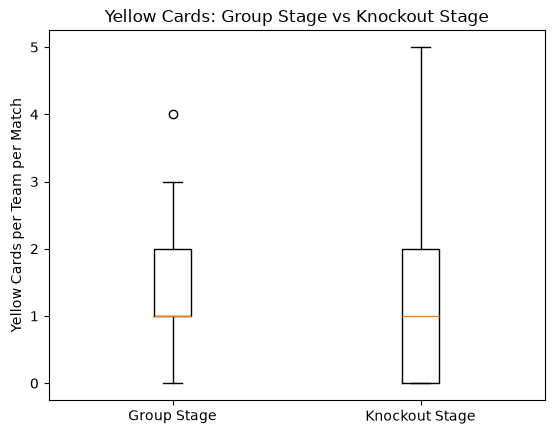

In [7]:
import matplotlib.pyplot as plt

plt.boxplot([sample_group, sample_knockout], tick_labels=["Group Stage", "Knockout Stage"])
plt.ylabel("Yellow Cards per Team per Match")
plt.title("Yellow Cards: Group Stage vs Knockout Stage")
plt.savefig("../outputs/figures/supriya_cards_boxplot.png", dpi=150, bbox_inches="tight")
plt.show()

In [10]:
from scipy import stats

mean_group = sample_group.mean()
sem_group = stats.sem(sample_group)
ci_group = stats.t.interval(confidence=0.95, df=len(sample_group)-1, loc=mean_group, scale=sem_group)

mean_knockout = sample_knockout.mean()
sem_knockout = stats.sem(sample_knockout)
ci_knockout = stats.t.interval(confidence=0.95, df=len(sample_knockout)-1, loc=mean_knockout, scale=sem_knockout)

print(f"Group stage — mean yellow cards: {mean_group:.2f}")
print(f"95% CI: ({ci_group[0]:.2f}, {ci_group[1]:.2f})")

print(f"\nKnockout stage — mean yellow cards: {mean_knockout:.2f}")
print(f"95% CI: ({ci_knockout[0]:.2f}, {ci_knockout[1]:.2f})")

Group stage — mean yellow cards: 1.33
95% CI: (0.95, 1.72)

Knockout stage — mean yellow cards: 1.33
95% CI: (0.79, 1.87)


In [11]:
# Check equality of variances (Levene's test)
levene_stat, levene_p = stats.levene(sample_group, sample_knockout)

print(f"Levene's test statistic = {levene_stat:.3f}")
print(f"p-value = {levene_p:.5f}")

alpha = 0.05
if levene_p < alpha:
    print("\nResult: Variances are significantly different (p < 0.05).")
    print("→ Welch's t-test (equal_var=False) is the appropriate choice.")
else:
    print("\nResult: No significant difference in variances (p >= 0.05).")
    print("→ Either Student's or Welch's t-test would be appropriate; Welch's is still a safe default.")

Levene's test statistic = 4.900
p-value = 0.03080

Result: Variances are significantly different (p < 0.05).
→ Welch's t-test (equal_var=False) is the appropriate choice.


### Note on t-test choice
A Levene's test for equality of variances was conducted (statistic = 4.900, p = 0.031), 
confirming the two groups have significantly different variances (Group stage SD = 1.03, 
Knockout stage SD = 1.45). This violates the equal-variance assumption of the standard 
Student's t-test, so Welch's t-test (equal_var=False) was used instead, as it does not 
require equal variances between groups.

In [9]:
# H0: mean yellow cards (Group stage) = mean yellow cards (Knockout stage)
# H1: mean yellow cards (Group stage) ≠ mean yellow cards (Knockout stage)

t_stat, p_value = stats.ttest_ind(sample_group, sample_knockout, equal_var=False)  # Welch's t-test

print(f"t-statistic = {t_stat:.3f}")
print(f"p-value = {p_value:.5f}")

alpha = 0.05
if p_value < alpha:
    print("\nResult: Reject H0 — there IS a statistically significant difference")
    print("in yellow cards between Group stage and Knockout stage.")
else:
    print("\nResult: Fail to reject H0 — no statistically significant difference")
    print("in yellow cards between Group stage and Knockout stage.")

t-statistic = 0.000
p-value = 1.00000

Result: Fail to reject H0 — no statistically significant difference
in yellow cards between Group stage and Knockout stage.
